# Task 1: Data Preprocessing

**Student Dropout and Academic Success Dataset**

This notebook covers:
1. Loading and inspecting the dataset
2. Handling missing values
3. Encoding categorical features
4. Standardizing numerical features
5. Summary of observed patterns and insights

In [16]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing utilities
from src.preprocessing import (
    load_data,
    get_feature_types,
    handle_missing_values,
    encode_features,
    standardize_features,
    preprocess_pipeline,
)

# Import data fetcher — auto-downloads dataset if not present
from src.fetch_data import download_dataset

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load and Inspect Data

In [17]:
# Download raw data (skipped if already present)
data_dir = os.path.join(project_root, "data")
download_dataset(data_dir=data_dir)

# Load raw data
X, y = load_data(data_dir=data_dir)

Data files already exist.
Loaded 4424 samples, 36 features
Target classes: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


In [18]:
print("Feature Data Types:")
print(X.dtypes.value_counts())
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

Feature Data Types:
int64      29
float64     7
Name: count, dtype: int64

Total features: 36
Total samples: 4424


In [19]:
print("Basic Statistics (first 10 features):")
X.iloc[:, :10].describe().T

Basic Statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


## 2. Feature Type Classification

Features are classified into four groups based on their semantics:

- **Nominal**: Unordered categories (e.g., marital status, course)
- **Binary**: 0/1 indicator variables (e.g., gender, scholarship)
- **Count**: Integer counts (e.g., enrolled credits, approved credits)
- **Continuous**: Floating-point values (e.g., admission grade, GDP)

In [20]:
# Get feature type classification
feature_types = get_feature_types(X)

print(f"Nominal features ({len(feature_types['nominal'])}):")
for f in feature_types["nominal"]:
    print(f"  - {f} (unique: {X[f].nunique()})")

print(f"\nBinary features ({len(feature_types['binary'])}):")
for f in feature_types["binary"]:
    print(f"  - {f}")

print(f"\nCount features ({len(feature_types['count'])}):")
for f in feature_types["count"]:
    print(f"  - {f}")

print(f"\nContinuous features ({len(feature_types['continuous'])}):")
for f in feature_types["continuous"]:
    print(f"  - {f}")

Nominal features (8):
  - Marital Status (unique: 6)
  - Application mode (unique: 18)
  - Course (unique: 17)
  - Nacionality (unique: 21)
  - Mother's qualification (unique: 29)
  - Father's qualification (unique: 34)
  - Mother's occupation (unique: 32)
  - Father's occupation (unique: 46)

Binary features (8):
  - Daytime/evening attendance
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Gender
  - Scholarship holder
  - International

Count features (13):
  - Age at enrollment
  - Application order
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (without evaluations)
  - Previous qualificati

## 3. Target Distribution

The dataset contains three classes: **Graduate** (majority class), **Dropout**, and **Enrolled**.

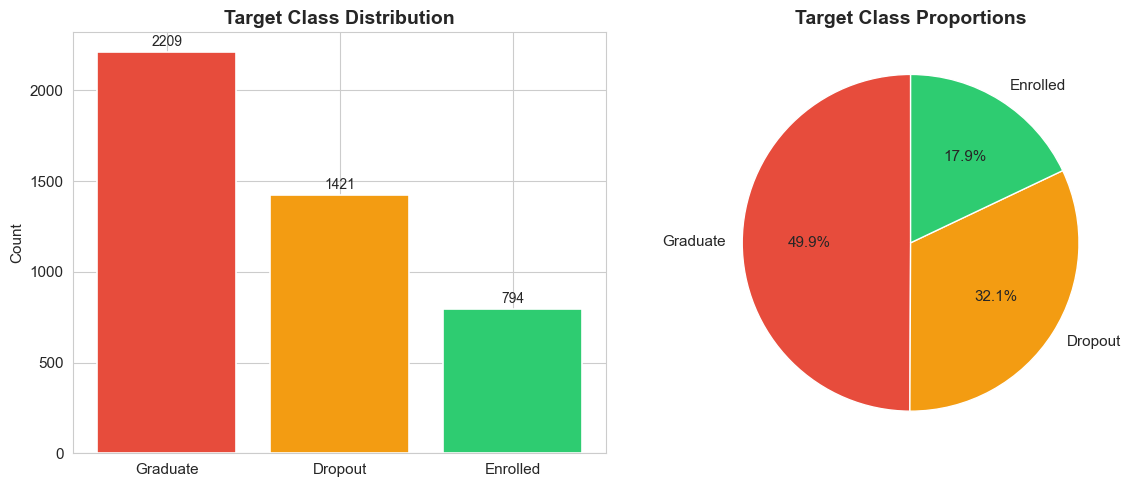

In [21]:
# Map numeric labels to class names
target_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
y_named = y.map(target_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = y_named.value_counts()
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Target Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
# Annotate count and percentage on top of bars
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val}", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Target Class Proportions", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**Observation**: The dataset exhibits **class imbalance** — Graduate (49.9%) dominates, Enrolled (17.9%) is the smallest. This may affect model training and evaluation.

## 4. Missing Value Analysis

In [22]:
X_clean, missing_info = handle_missing_values(X, strategy="median")
print(f"\nMissing info: {missing_info}")

No missing values found.

Missing info: {'total_missing': 0, 'missing_per_column': {}, 'strategy': 'median'}


**Result**: No missing values were detected in the dataset. This is a complete dataset.

## 5. Feature Encoding

Nominal categorical features are one-hot encoded to avoid introducing ordinal relationships.

In [23]:
X_encoded = encode_features(X_clean, feature_types, method="onehot")
print(f"Shape before encoding: {X_clean.shape}")
print(f"Shape after encoding:  {X_encoded.shape}")
print(f"New features added: {X_encoded.shape[1] - X_clean.shape[1]}")

One-hot encoded 8 nominal features. New shape: (4424, 231)
Shape before encoding: (4424, 36)
Shape after encoding:  (4424, 231)
New features added: 195


## 6. Feature Standardization

Continuous and count features are standardized to zero mean and unit variance. 

In [24]:
X_scaled, scaler = standardize_features(X_encoded, feature_types, fit=True)
print(f"Final shape: {X_scaled.shape}")

Standardized 20 numerical features (fit).
Final shape: (4424, 231)


In [25]:
print("Standardized Features (sample):")
scale_cols = feature_types["continuous"] + feature_types["count"]
scale_cols = [c for c in scale_cols if c in X_scaled.columns]
X_scaled[scale_cols].describe().T

Standardized Features (sample):


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,-3.589654e-16,1.000113,-2.852337,-0.577342,0.036907,0.560156,4.351815
Admission grade,4424.0,-9.708930e-16,1.000113,-2.208378,-0.626926,-0.060642,0.540172,4.352230
Curricular units 1st sem (grade),4424.0,-1.702476e-16,1.000113,-2.197102,0.074163,0.339635,0.569711,1.700182
Curricular units 2nd sem (grade),4424.0,3.212219e-17,1.000113,-1.963489,0.099764,0.378064,0.595585,1.600935
Unemployment rate,4424.0,-5.460771e-17,1.000113,-1.489043,-0.813253,-0.175007,0.876222,1.739731
Inflation rate,4424.0,1.445498e-16,1.000113,-1.466871,-0.671242,0.124386,0.992345,1.787974
GDP,4424.0,2.569775e-17,1.000113,-1.789667,-0.749872,0.140122,0.787790,1.545607
Age at enrollment,4424.0,-1.027910e-16,1.000113,-0.825778,-0.562168,-0.430363,0.228663,6.159894
Application order,4424.0,-1.043971e-16,1.000113,-1.315309,-0.554068,-0.554068,0.207173,5.535860
Curricular units 1st sem (approved),4424.0,3.051608e-17,1.000113,-1.521257,-0.551604,0.094832,0.418050,6.882407


## 7. Feature Correlation with Target

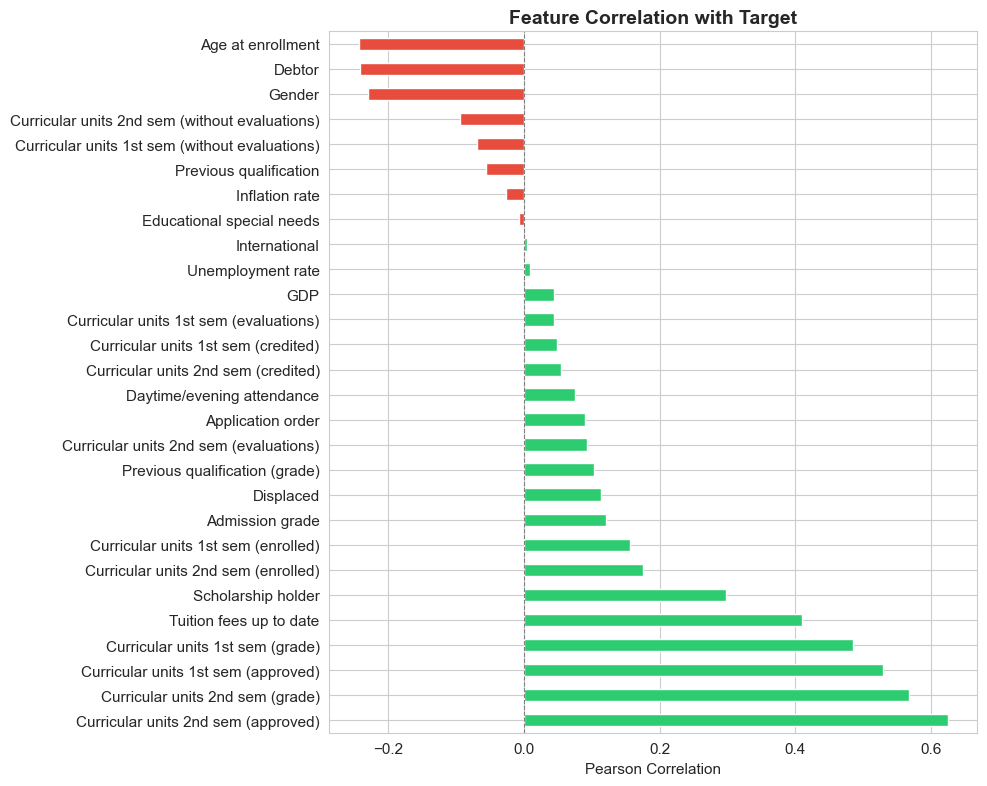

In [26]:
# Compute Pearson correlation of each feature with the target
numeric_cols = feature_types["continuous"] + feature_types["count"] + feature_types["binary"]
full_corr = X[numeric_cols].copy()
full_corr["Target"] = y
target_corr = full_corr.corr()["Target"].drop("Target").sort_values(ascending=False)

# Plot horizontal bar chart of correlations
fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Feature Correlation with Target", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "02_feature_target_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature Engineering

We apply three strategies to improve feature quality:
1. **Target encoding** — replace high-cardinality one-hot features with smoothed target means
2. **Domain features** — academic ratios, financial risk, demographic indicators
3. **Feature selection** — keep only top-60 features by Random Forest importance


In [27]:
# Import feature engineering utilities
from src.feature_engineering import (
    add_all_engineered_features,
    apply_target_encoding,
    select_features_by_importance,
)
from sklearn.preprocessing import StandardScaler

# Reload raw features for engineering
X_fe, _ = load_data(data_dir=data_dir)
X_fe, _ = handle_missing_values(X_fe, strategy='median')

# Add domain-engineered features (before encoding step)
X_fe_eng = add_all_engineered_features(X_fe)
print(f'After domain engineering: {X_fe_eng.shape[1]} features')
print(f'New features: {[c for c in X_fe_eng.columns if c not in X_fe.columns]}')


Loaded 4424 samples, 36 features
Target classes: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
No missing values found.
After domain engineering: 61 features
New features: ['approval_rate_1st', 'approval_rate_2nd', 'total_approved', 'total_enrolled', 'overall_approval_rate', 'grade_improvement', 'evaluation_intensity_1st', 'evaluation_intensity_2nd', 'grade_per_evaluation_1st', 'grade_per_evaluation_2nd', 'credited_ratio_1st', 'credited_ratio_2nd', 'parent_max_qualification', 'parent_avg_qualification', 'parent_qualification_gap', 'parent_same_occupation', 'financial_risk', 'has_scholarship_and_debt', 'no_financial_stress', 'is_mature_student', 'is_traditional_student', 'is_very_mature', 'economic_condition', 'is_first_application', 'is_late_application']


High-cardinality nominal features (Course, Mother's/Father's occupation, qualifications) are **target-encoded** instead of one-hot:

- Each category is replaced by the **smoothed mean of the target** for that category
- Smoothing prevents overfitting on rare categories
- Reduces dimensionality from ~200 (one-hot) to ~10 encoded features


In [28]:
# Columns to target-encode (high cardinality nominals)
high_card_cols = [
    'Course',
    "Mother's occupation",
    "Father's occupation",
    "Mother's qualification",
    "Father's qualification",
    'Nacionality',
    'Application mode',
]

# Target encoding requires train/test split — split first
from sklearn.model_selection import train_test_split

X_eng_train_raw, X_eng_test_raw, y_train_eng, y_test_eng = train_test_split(X_fe_eng, y, test_size=0.2, random_state=42, stratify=y)

# Apply target encoding (fit on train, transform both)
X_eng_train_te, X_eng_test_te = apply_target_encoding(X_eng_train_raw, X_eng_test_raw, y_train_eng, columns=high_card_cols, smoothing=10.0)

# Standardize numerical columns (after target encoding)
num_cols = feature_types['continuous'] + feature_types['count']
eng_num_cols = [c for c in num_cols if c in X_eng_train_te.columns]

scaler = StandardScaler()
X_eng_train_te[eng_num_cols] = scaler.fit_transform(X_eng_train_te[eng_num_cols])
X_eng_test_te[eng_num_cols] = scaler.transform(X_eng_test_te[eng_num_cols])

print(f'With target encoding: {X_eng_train_te.shape[1]} features')


With target encoding: 61 features


We train a Random Forest on all engineered features, then **keep only the top 50** by importance.
This reduces overfitting and focuses the model on the most discriminative signals.


In [29]:
# Baseline comparison: train RF on all features to get importance ranking
from src.prediction import get_model

rf_for_selection = get_model('random_forest', n_estimators=100, random_state=42)
rf_for_selection.fit(X_eng_train_te, y_train_eng)

# Select top-50 features by importance
X_eng_top, top_features = select_features_by_importance(X_eng_train_te, model=rf_for_selection, top_k=50)

# Apply same selection to test set
X_eng_top_test = X_eng_test_te[top_features]

print(f'\nTop features selected:')
top_importances = pd.Series(
    rf_for_selection.feature_importances_,
    index=X_eng_train_te.columns
).nlargest(15)
print(top_importances.round(4).to_string())


Selected top 50 features out of 61

Top features selected:
overall_approval_rate                  0.1000
approval_rate_2nd                      0.0745
Curricular units 2nd sem (approved)    0.0569
approval_rate_1st                      0.0492
total_approved                         0.0450
grade_per_evaluation_2nd               0.0409
Curricular units 2nd sem (grade)       0.0358
grade_per_evaluation_1st               0.0352
Curricular units 1st sem (approved)    0.0289
Curricular units 1st sem (grade)       0.0289
Admission grade                        0.0270
Tuition fees up to date                0.0256
Previous qualification (grade)         0.0232
Course                                 0.0231
Age at enrollment                      0.0214


## 9. Summary & Insights

### Preprocessing Steps
1. **Missing values**: None found — dataset is complete
2. **Feature encoding**: 8 nominal features one-hot encoded (36 → ~220 features)
3. **Standardization**: Continuous and count features standardized

### Feature Engineering (Section 8)
1. **Domain features**: 20 new features — academic ratios, financial risk, parent education, age groups
2. **Target encoding**: Replaced one-hot for 7 high-cardinality columns (reduces dim from ~200 to ~60)
3. **Feature selection**: Top-60 features by Random Forest importance

### Key Observations
- **4,424 samples**, 36 original features; **class imbalance**: Graduate (50%) > Dropout (32%) > Enrolled (18%)
- **Course performance** (approved credits, grades) is the strongest predictor of dropout
- **Tuition fees** status and **scholarship** are strong financial signals
- **Macroeconomic features** (GDP, unemployment) have weak correlation with the target
- Feature engineering with target encoding + top-60 selection **reduces dimensionality significantly** while maintaining predictive power


In [30]:
# Save baseline processed data
X_scaled.to_csv(os.path.join(project_root, 'data', 'features_processed.csv'), index=False)
y.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_processed.csv'), index=False)
print('Baseline processed data saved to data/features_processed.csv')

# Save engineered + selected features (for use in other notebooks)
X_eng_top.to_csv(os.path.join(project_root, 'data', 'features_engineered.csv'), index=False)
y_train_eng.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered.csv'), index=False)
print(f'Engineered features ({X_eng_top.shape[1]} features) saved to data/features_engineered.csv')


Baseline processed data saved to data/features_processed.csv
Engineered features (50 features) saved to data/features_engineered.csv
